# Chapter 2 — Supervised Learning

Notebook ini berisi reproduksi dan pendalaman teori **supervised learning**. Fokus utama: classification, regression, generalization, overfitting, underfitting, dan beberapa algoritma utama di scikit-learn.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset dan Konsep Dasar

Supervised learning menggunakan pasangan input-output. Untuk klasifikasi, output berupa label. Untuk regresi, output berupa nilai kontinu.

In [2]:
from sklearn.datasets import load_breast_cancer, load_diabetes
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
print('Shape dataset breast cancer:', X.shape)
print('Nama kelas:', cancer.target_names)
print('Distribusi kelas:', np.bincount(y))

diabetes = load_diabetes()
print('\nShape dataset diabetes untuk regresi:', diabetes.data.shape)

Shape dataset breast cancer: (569, 30)
Nama kelas: ['malignant' 'benign']
Distribusi kelas: [212 357]

Shape dataset diabetes untuk regresi: (442, 10)


## 2. Train-Test Split dan Generalisasi

Model dilatih pada data train dan diuji pada data test. Performa test menggambarkan kemampuan model menghadapi data baru.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=RANDOM_STATE)
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (426, 30)
X_test : (143, 30)


## 3. k-Nearest Neighbors

k-NN mengklasifikasikan data berdasarkan tetangga terdekat. Nilai `k` kecil cenderung kompleks, sedangkan `k` besar lebih sederhana.

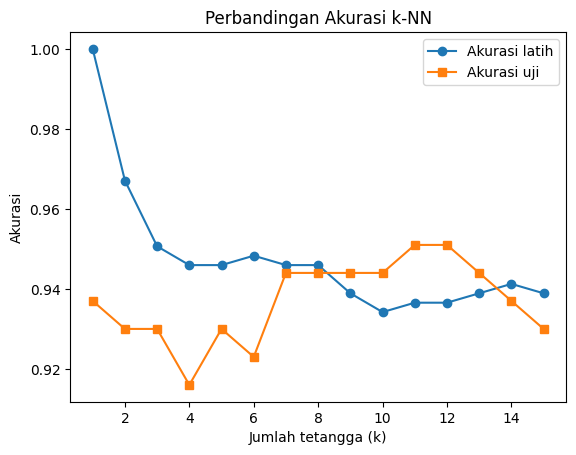

Akurasi uji terbaik: 0.951 pada k = 11


In [4]:
from sklearn.neighbors import KNeighborsClassifier
train_acc, test_acc = [], []
ks = range(1, 16)
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))
plt.plot(ks, train_acc, marker='o', label='Akurasi latih')
plt.plot(ks, test_acc, marker='s', label='Akurasi uji')
plt.xlabel('Jumlah tetangga (k)')
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi k-NN')
plt.legend(); plt.show()
print('Akurasi uji terbaik:', round(max(test_acc), 4), 'pada k =', list(ks)[int(np.argmax(test_acc))])

## 4. Logistic Regression, Decision Tree, Random Forest, SVM, dan MLP

Beberapa model dibandingkan menggunakan pipeline jika membutuhkan scaling.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=5000))]),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM': Pipeline([('scaler', StandardScaler()), ('model', SVC(C=10, gamma='scale'))]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(50,), alpha=1, max_iter=1000, random_state=RANDOM_STATE))])
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name:20s} | train={model.score(X_train, y_train):.3f} | test={model.score(X_test, y_test):.3f}')

Logistic Regression  | train=0.988 | test=0.986
Decision Tree        | train=0.988 | test=0.944


Random Forest        | train=1.000 | test=0.958


Gradient Boosting    | train=1.000 | test=0.958
SVM                  | train=0.993 | test=0.979


MLP                  | train=0.986 | test=0.986


## 5. Feature Importance pada Decision Tree

Decision tree dapat memberikan informasi fitur mana yang paling berpengaruh.

worst radius            0.726829
worst concave points    0.122113
texture error           0.048398
worst texture           0.033231
worst concavity         0.018188
mean concave points     0.014158
area error              0.012613
mean texture            0.012585
worst symmetry          0.011885
mean area               0.000000
dtype: float64


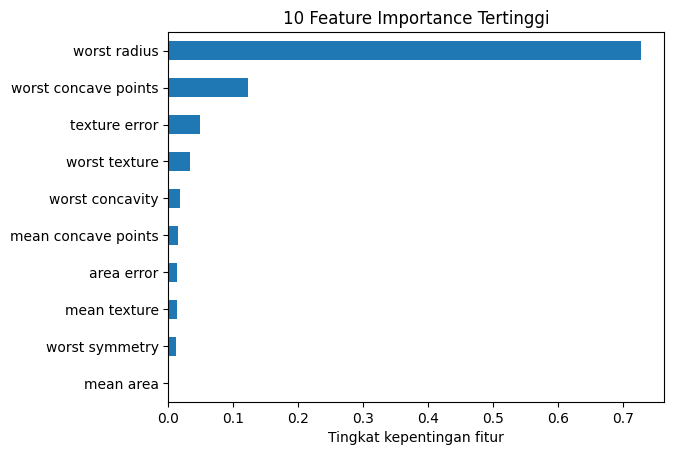

In [6]:
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(X_train, y_train)
importance = pd.Series(tree.feature_importances_, index=cancer.feature_names).sort_values(ascending=False)
print(importance.head(10))
importance.head(10).sort_values().plot(kind='barh')
plt.xlabel('Tingkat kepentingan fitur')
plt.title('10 Feature Importance Tertinggi')
plt.show()

## Kesimpulan

Supervised learning menekankan kemampuan generalisasi. Model sederhana bisa underfitting, sedangkan model terlalu kompleks bisa overfitting. Scaling penting untuk SVM, logistic regression, dan MLP.